**Tableau Dashboard**: https://public.tableau.com/app/profile/clarence.manzo/viz/P0M1_clarence_manzo/BookExchangeInsightsDashboard?publish=yes

# i. Introduction

Name  : Clarence Manzo

This notebook is made for a book-exchange platform to analyze and compare the most popular types of books for exchange.

# ii. Problem Statement and Dataset Description

## Project Topic
Optimizing Book Exchange Inventory and Promotion Strategy Based on Popularity, Ratings, and Market Trends.

## Background
A book-exchange platform operates by matching supply (available books) with demand (books requested for swapping) across different countries. However, the platform currently lacks data-driven insights to determine which books should be prioritized for inventory acquisition, promotion, and regional marketing.

With a large dataset containing book attributes such as genre, ratings, publication year, bestseller status, and movie adaptations, there is an opportunity to  uncover demand patterns and optimize business decisions.


## Problem Statement
The client needs a data-driven analysis to identify and compare the most popular types of books for exchange across different countries, measured through metrics such as average ratings, popularity distribution, and bestseller frequency, to optimize inventory planning and promotional strategies within two weeks for quarterly decision-making.

**Specific**: The client needs to identify which types of books (by genre, rating, age category, and adaptation status) are most popular for exchange across different countries.

**Measurable**: Success will be measured by the ability to rank and compare books and categories using metrics such as average ratings, popularity distribution, and bestseller frequency.

**Achievable**: The dataset contains sufficient variables (ratings, genres, popularity country, bestseller status) to conduct both descriptive and inferential analysis.

**Relevant**: Improving inventory planning and promotion strategies directly impacts exchange success rates, user satisfaction, and operational efficiency.

**Time-Bound**: The analysis and dashboard will be completed within two weeks and used for quarterly strategic planning.

## Project Objectives
- Identify the most in-demand book characteristics for exchanges.
- Understand how popularity varies by country and genre.
- Analyze whether high ratings and bestseller status significantly influence exchange demand.
- Provide actionable insights through dashboard for decision-making.


## Project Usage
- Support inventory acquisition decisions.
- Guide promotional campaigns.
- Optimize regional marketing strategies.
- Improve recommendation and swapping success rates on the platform.

## Target User/Client
Target client: Management and Strategy Team of a Book Exchange Platform

Target users: Business Analysts, Marketing Team

## Problems Breakdown
1. Which book genres are most popular for exchanging?
2. Do books with higher average ratings tend to be more popular for exchanges?
3. Are books adapted into movies more popular for exchange compared to non-adapted books?
4. How does the popularity of exchanged books vary by publication year?
5. How is the data distribution of book ratings in the exchange platform?
6. Is there a statistically significant difference in average ratings between bestseller and non-bestseller books?

## Dataset Source
URL: https://www.kaggle.com/datasets/sergiykovalchuck/the-most-popular-books-for-exchanging?resource=download

The dataset is taken from the Kaggle Website, as the title is *"The Most Popular Books for Exchanging"*.

## Dataset Description
The dataset titled “The Most Popular Books for Exchanging” contains information on books that are frequently requested or swapped on a book-exchange platform. Each record represents a single book with complete descriptive and popularity indicator information.

**Column Descriptions**:
- id (Integer): A unique ID for the record.
- title (String): Book's title.
- author (String): Author's name.
- genre (String): Book's genre.
- language (String): The language in which the book is written or published.
- publicationYear (Integer): Book's published year.
- publisher (String): Publisher's name.
- description (String): The book's synopsis.
- pageCount (Integer): The total number of pages in the book.
- tags (String): Comma-separated keywords or tags describing the book's themes.
- rating_average (Float): The average user rating.
- most_popular_country (String): The country where the book is most requested.
- bestseller_status (Boolean): A recognized bestseller book or not.
- awards (String): A list of awards the book has won.
- age_category (String): The target age group.
- adapted_to_movie (Boolean): The book has been adapted into a film or not.
- movie_release_year (Float): The year the movie adaptation was released.
- isbn (String): The International Standard Book Number, a unique numeric commercial book identifier.

# iii. Data Loading

In [21]:
# Import libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
# Load dataset to a dataframe
df = pd.read_csv('P0M1_clarence_manzo_dataset.csv')

# View first 10 records
df.head(10)

,id,title,author,genre,language,publicationYear,publisher,description,pageCount,tags,rating_average,most_popular_country,bestseller_status,awards,age_category,adapted_to_movie,movie_release_year,isbn
0,1,Harry Potter and the Sorcerer's Stone,J.K. Rowling,Fantasy,English,1997,Bloomsbury,A young wizard discovers his magical heritage ...,309,"magic,school,adventure",4.89,UK,True,"Smarties Prize,British Book Award",Children,True,2001.0,978-0747532743
1,2,To Kill a Mockingbird,Harper Lee,Southern Gothic,English,1960,J.B. Lippincott & Co.,A lawyer in the Depression-era South defends a...,281,"classic,law,racism,history",4.85,USA,True,Pulitzer Prize,Adult,True,1962.0,978-0061120084
2,3,1984,George Orwell,Dystopian,English,1949,Secker & Warburg,A dystopian social science fiction novel and c...,328,"politics,scifi,totalitarianism",4.80,UK,True,Prometheus Hall of Fame,Adult,True,1984.0,978-0451524935
3,4,The Great Gatsby,F. Scott Fitzgerald,Tragedy,English,1925,Charles Scribner's Sons,A story of the fabulously wealthy Jay Gatsby a...,180,"classic,wealth,romance,jazz age",4.40,USA,True,NaN,Adult,True,2013.0,978-0743273565
4,5,The Hobbit,J.R.R. Tolkien,Fantasy,English,1937,George Allen & Unwin,"Bilbo Baggins, a hobbit, is swept into an epic...",310,"adventure,dragons,magic",4.75,UK,True,Keith Barker Millennium Book Award,Children,True,2012.0,978-0547928227
5,6,Pride and Prejudice,Jane Austen,Romance,English,1813,T. Egerton,The romantic clash between the opinionated Eli...,279,"classic,love,victorian,satire",4.65,UK,True,NaN,Adult,True,2005.0,978-0141439518
6,7,The Catcher in the Rye,J.D. Salinger,Realism,English,1951,"Little, Brown and Company","Holden Caulfield, a teenager from New York, na...",234,"teen,classic,angst,coming-of-age",4.05,USA,True,NaN,Young Adult,False,NaN,978-0316769488
7,8,The Da Vinci Code,Dan Brown,Thriller,English,2003,Doubleday,Robert Langdon investigates a murder in the Lo...,489,"mystery,religion,art,conspiracy",4.30,USA,True,British Book Award,Adult,True,2006.0,978-0307474278
8,9,The Hunger Games,Suzanne Collins,Dystopian,English,2008,Scholastic,Katniss Everdeen volunteers to take her sister...,374,"survival,action,romance,scifi",4.72,USA,True,California Young Reader Medal,Young Adult,True,2012.0,978-0439023481
9,10,The Lord of the Rings,J.R.R. Tolkien,Fantasy,English,1954,George Allen & Unwin,Frodo Baggins must destroy the One Ring to def...,1178,"epic,magic,war,adventure",4.92,UK,True,International Fantasy Award,Adult,True,2001.0,978-0544003415


The first 10 data shows that most popular books are English bestsellers, mainly from the UK and USA. Many popular titles have been adapted into movies, suggesting these factors contribute to higher exchange demand. Most of the book's target audience is also for adult and young adult.

In [4]:
# Print dataframe's shape (rows and columns)
df.shape

(990, 18)

There's a total of 990 records of book with 18 columns/attributes.

In [5]:
# Show the missing values and data types from each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    990 non-null    int64  
 1   title                 990 non-null    object 
 2   author                990 non-null    object 
 3   genre                 990 non-null    object 
 4   language              990 non-null    object 
 5   publicationYear       990 non-null    int64  
 6   publisher             990 non-null    object 
 7   description           990 non-null    object 
 8   pageCount             990 non-null    int64  
 9   tags                  990 non-null    object 
 10  rating_average        990 non-null    float64
 11  most_popular_country  990 non-null    object 
 12  bestseller_status     990 non-null    bool   
 13  awards                384 non-null    object 
 14  age_category          990 non-null    object 
 15  adapted_to_movie      9

The overall dataset is relatively clean, although the awards attribute has 600 missing values and movie_release_year has 350 missing values. The movie_release_year is also need to be converted into integer instead of float.

In [6]:
# Show the summary of numerical data distribution
df.describe()

,id,publicationYear,pageCount,rating_average,movie_release_year
count,990.000000,990.000000,990.000000,990.000000,642.000000
mean,502.079798,1962.996970,378.904040,4.061949,1997.704050
std,289.286296,195.433466,190.567626,0.241120,22.531925
min,1.000000,-750.000000,22.000000,3.140000,1926.000000
25%,252.250000,1965.250000,256.000000,3.920000,1987.000000
50%,503.500000,1997.000000,341.500000,4.070000,2005.000000
75%,752.750000,2010.000000,452.750000,4.220000,2015.000000
max,1003.000000,2023.000000,1463.000000,4.950000,2025.000000


The average publication year is around 1963. The typical book contains about 379 pages and has an average rating of 4 out of 5. There's total 642 records of movie release years from 990 total records, indicates that there are 642 books that were adapted to movies. Most movie adaptations were released in the year of 1997. The presence of negative number for publication years indicates that it may require cleaning before further analysis.

In [7]:
# Show the summary of object data distribution
df.describe(include='object')

,title,author,genre,language,publisher,description,tags,most_popular_country,awards,age_category,isbn
count,990,990,990,990,990,990,990,990,384,990,990
unique,990,555,81,13,297,990,968,39,128,3,986
top,Harry Potter and the Sorcerer's Stone,Stephen King,Fantasy,English,Doubleday,A young wizard discovers his magical heritage ...,"mystery,kidnap,twist",USA,Goodreads Choice Award,Adult,978-0062073556
freq,1,26,155,957,48,1,3,588,43,778,2


The dataset has a high diversity in book titles, authors, genres, and publishers which indicates a broad and varied catalog.

Most books are written in English and are most popular in the USA, suggesting that English-speaking markets is a strong exchange demand.

The most common genre is fantasy and the dominant age category is adult.

In [8]:
# Print column's name
df.columns

Index(['id', 'title', 'author', 'genre', 'language', 'publicationYear',
       'publisher', 'description', 'pageCount', 'tags', 'rating_average',
       'most_popular_country', 'bestseller_status', 'awards', 'age_category',
       'adapted_to_movie', 'movie_release_year', 'isbn'],
      dtype='object')

The columns' name are already up to standard, so any further formatting/renaming is not needed.

In [9]:
# Print the number of unique values from every column
df.nunique()

id                      990
title                   990
author                  555
genre                    81
language                 13
publicationYear         175
publisher               297
description             990
pageCount               457
tags                    968
rating_average          125
most_popular_country     39
bestseller_status         2
awards                  128
age_category              3
adapted_to_movie          2
movie_release_year       95
isbn                    986
dtype: int64

# iv. Data Cleaning

In [10]:
# Replace missing values with the rounded average movie's release year
df["movie_release_year"] = df["movie_release_year"].fillna(round(df["movie_release_year"].mean(), 0))

# Ensure there are no missing values
df["movie_release_year"].isna().sum()

0

In [11]:
# Replace missing values with None
df["awards"] = df["awards"].fillna("None")

# Ensure there are no missing values
df["movie_release_year"].isna().sum()

0

In [15]:
# Convert movie release year data type from float to integer
df["movie_release_year"] = df["movie_release_year"].astype(int)

In [17]:
# Check 1 more time to ensure all data types are consistent and no missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    990 non-null    int64  
 1   title                 990 non-null    object 
 2   author                990 non-null    object 
 3   genre                 990 non-null    object 
 4   language              990 non-null    object 
 5   publicationYear       990 non-null    int64  
 6   publisher             990 non-null    object 
 7   description           990 non-null    object 
 8   pageCount             990 non-null    int64  
 9   tags                  990 non-null    object 
 10  rating_average        990 non-null    float64
 11  most_popular_country  990 non-null    object 
 12  bestseller_status     990 non-null    bool   
 13  awards                990 non-null    object 
 14  age_category          990 non-null    object 
 15  adapted_to_movie      9

In [19]:
# Drop unecessary columns
df.drop(["description", "isbn"], inplace=True, axis=1)

# View dataframe
df.head(5)

,id,title,author,genre,language,publicationYear,publisher,pageCount,tags,rating_average,most_popular_country,bestseller_status,awards,age_category,adapted_to_movie,movie_release_year
0,1,Harry Potter and the Sorcerer's Stone,J.K. Rowling,Fantasy,English,1997,Bloomsbury,309,"magic,school,adventure",4.89,UK,True,"Smarties Prize,British Book Award",Children,True,2001
1,2,To Kill a Mockingbird,Harper Lee,Southern Gothic,English,1960,J.B. Lippincott & Co.,281,"classic,law,racism,history",4.85,USA,True,Pulitzer Prize,Adult,True,1962
2,3,1984,George Orwell,Dystopian,English,1949,Secker & Warburg,328,"politics,scifi,totalitarianism",4.80,UK,True,Prometheus Hall of Fame,Adult,True,1984
3,4,The Great Gatsby,F. Scott Fitzgerald,Tragedy,English,1925,Charles Scribner's Sons,180,"classic,wealth,romance,jazz age",4.40,USA,True,None,Adult,True,2013
4,5,The Hobbit,J.R.R. Tolkien,Fantasy,English,1937,George Allen & Unwin,310,"adventure,dragons,magic",4.75,UK,True,Keith Barker Millennium Book Award,Children,True,2012


In [43]:
# Remove negative valued publication years
df = df[df['publicationYear'] > 0]

In [44]:
# Save cleaned data to CSV file
df.to_csv("P0M1_clarence_manzo_dataset_cleaned.csv", index=False)

# v. Exploration and Analysis

1. Which book genres are most popular for exchanging?

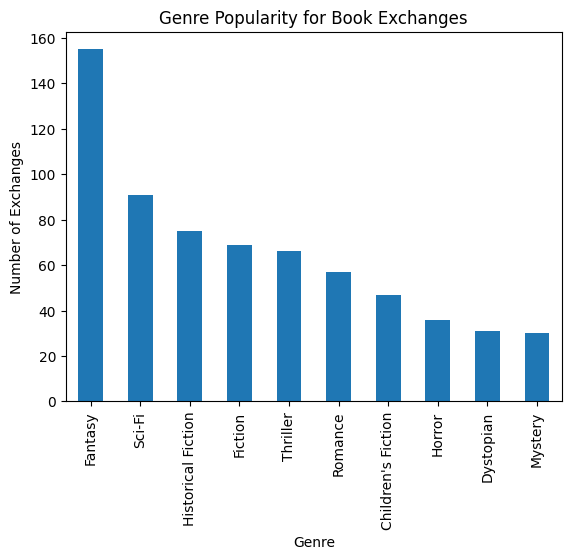

In [45]:
# Get the top 10 most popular genres
genre_counts = df['genre'].value_counts().head(10)

# Plot the bar chart
plt.figure()
genre_counts.plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('Number of Exchanges')
plt.title('Genre Popularity for Book Exchanges')
plt.show()

Based on the top 10 genres among 81 genres, fantasy is the most popular genre for book exchanges by a clear margin, followed by sci-fi and historical fiction. However, genres such as horror, dystopian, and mystery show relatively lower exchange popularity compared to the top genres.

2. Do books with higher average ratings tend to be more popular for exchanges?

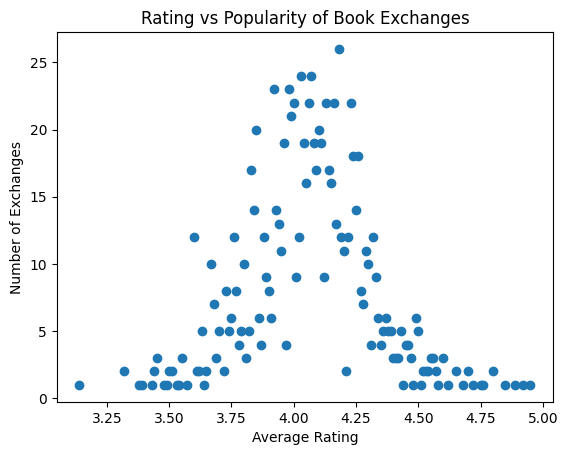

In [ ]:
# Calculate exchange counts by rating
exchange_count_by_rating = df.groupby(['rating_average']).size().reset_index(name='exchange_count')

# Plot the scatter plot
plt.figure()
plt.scatter(exchange_count_by_rating['rating_average'], exchange_count_by_rating['exchange_count'])
plt.xlabel('Average Rating')
plt.ylabel('Number of Exchanges')
plt.title('Rating vs Popularity of Book Exchanges')
plt.show()

Based on the chart, books with medium ratings (around 3.75–4.25) tend to have higher exchange counts, indicating greater popularity. However, very highly rated books have less exchange counts. In conclusion, ratings do influence popularity but are not the sole factor exchange demand.

3. Are books adapted into movies more popular for exchange compared to non-adapted books?

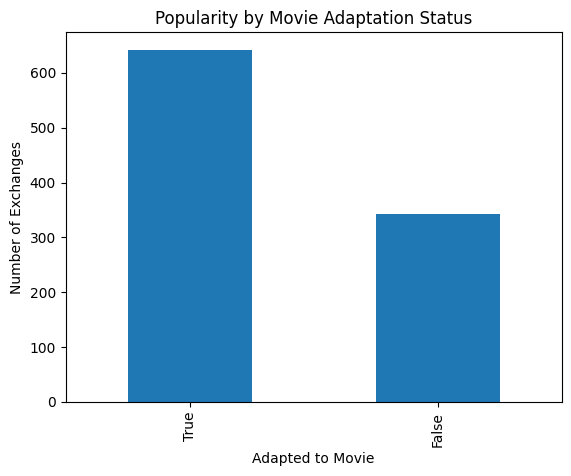

In [47]:
# Calculate the book's exchange number by movie adaptation status
movie_adaptation_counts = df['adapted_to_movie'].value_counts()

# Plot the bar chart
plt.figure()
movie_adaptation_counts.plot(kind='bar')
plt.xlabel('Adapted to Movie')
plt.ylabel('Number of Exchanges')
plt.title('Popularity by Movie Adaptation Status')
plt.show()

Books with movie adaptation has significantly higher number of exchanges than non-adapted books. So, movie adaptations will increase book's popularity and demand on the exchange platform.

4. How does the popularity of exchanged books vary by publication year?

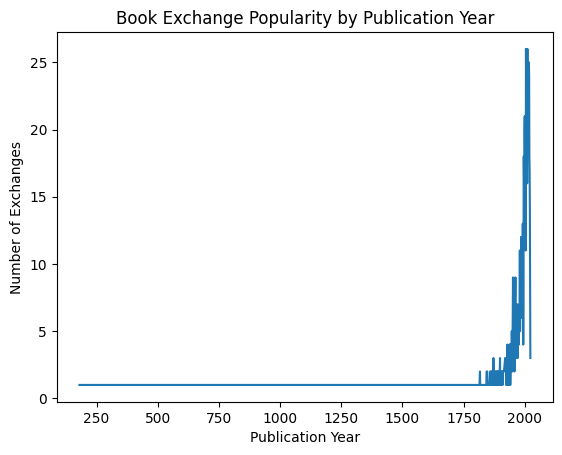

In [48]:
# Calculate number of exchanges by publication year
yearly_popularity = df.groupby('publicationYear').size().reset_index(name='exchange_count')

# Plot the line chart
plt.figure()
plt.plot(yearly_popularity['publicationYear'], yearly_popularity['exchange_count'])
plt.xlabel('Publication Year')
plt.ylabel('Number of Exchanges')
plt.title('Book Exchange Popularity by Publication Year')
plt.show()

Book exchange popularity for the very old publication years (below 1750) is very low and start to increases from around the year 1800. Than, it increases sharply for more recent years after the mid-1900s. It means that newer and more modern books tend to be exchanged more than older books. However, this chart is hard to analyze since it is extremely skewed. Filtered line chart is necessary for further detailed analysis.

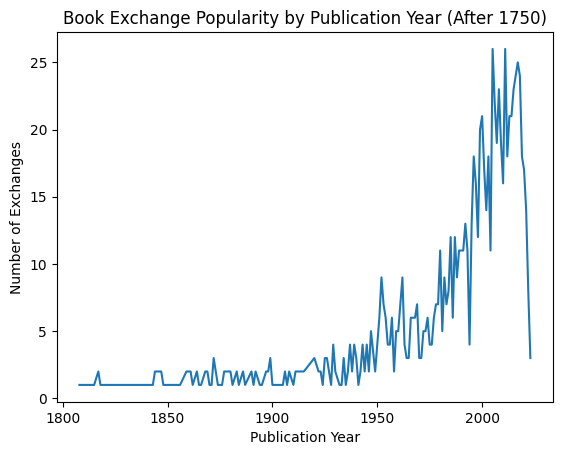

In [ ]:
# Filter publication year
df_filtered = df[df['publicationYear'] > 1750]

# Calculate number of exchanges by publication year
yearly_popularity = df_filtered.groupby('publicationYear').size().reset_index(name='exchange_count')

# Plot the line chart with the filtered data
plt.figure()
plt.plot(yearly_popularity['publicationYear'], yearly_popularity['exchange_count'])
plt.xlabel('Publication Year')
plt.ylabel('Number of Exchanges')
plt.title('Book Exchange Popularity by Publication Year (After 1750)')
plt.show()

The popularity of exchanged books increases steadily for books published after 1750, with a sharp rise from the year 1950 onward. This still indicates the same like previous one, where more recent books are exchanged significantly more often, reflecting stronger demand.

5. How is the data distribution of book ratings in the exchange platform?

In [ ]:
# Calculate rating's mean, median, standard deviation, skewness, and kurtosis
print('Average rating:', df['rating_average'].mean())
print('Median rating:', df['rating_average'].median())
print('Standard Deviation of rating:',df['rating_average'].std())
print("Skewness of product rating:", df['rating_average'].skew())
print("Kurtosis of product rating:", df['rating_average'].kurtosis())

Average rating: 4.06248730964467
Median rating: 4.07
Standard Deviation of rating: 0.24121686362298198
Skewness of product rating: 0.0426966106253225
Kurtosis of product rating: 0.7948666398084692


The book rating's average and median are the same, indicating that book ratings is normally distributed.

The standard deviation indicates very low variability in ratings, meaning users generally rate books consistently high.

The skewness value shows that the ratings distribution is symmetric.

The kurtosis shows a slight peaked distribution as the ratings are clustered in the center with few extreme values.

6. Is there a statistically significant difference in average ratings between bestseller and non-bestseller books?

Null hypothesis (H0): No difference in average ratings between bestseller and non-bestseller books.

Alternative hypothesis (H1): A significant difference in average ratings between bestseller and non-bestseller books.

In [52]:
# Ratings by bestseller status
bestseller = df[df['bestseller_status'] == True]['rating_average']
non_bestseller = df[df['bestseller_status'] == False]['rating_average']

# Perform independent two-sample t-test
t_stat, p_val = stats.ttest_ind(bestseller, non_bestseller)

# Print results
print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 2.394233167721069
P-value: 0.01684167570832693


Null hypothesis is rejected because the p-value is below 0.05. In conclusion, there is a significant difference in average ratings between bestseller and non-bestseller books. It implys that bestseller books tend to be rated differently compared to non-bestseller books.

# vi. Conclusion

The analysis shows that fantasy, sci-fi, and historical fiction should be prioritized. Books with medium ratings perform better than extremely high-rated books, indicating that popularity is influenced by broader accessibility and audience reach. Books with movie adaptations is great for promotion due to the high demand. Additionally, newer books should be focused more than older books.

Book ratings across the platform are stable, providing a reliable basis for comparison. Bestseller books should be prioritized as well. These insights will improve the platform in inventory prioritization, promotional focus, and strategic planning.